In [105]:
import collocation_WEB as cWEB
import numpy as np
import matplotlib.pyplot as plt
import importlib
import Geomertry
import PDE_testcases
import mesh
import lightning_laplace
import network_defs as netdefs
import torch
torch.set_default_dtype(torch.float64)

WEB-Spline Collocation: degree=4, H=200, domain={'x1': -1, 'x2': 1, 'y1': -1, 'y2': 1}, case=11
Domain transform: [0,1]² → [-1,1]×[-1,1]
Laplacian factors in grid coords: ax=1/scale_x^2=2.500e-01, ay=1/scale_y^2=2.500e-01
Classification...
  Inner B-splines: 23788
  Outer B-splines: 1500
  Inner element arrays: 22326
Building extension matrix...
  Extension matrix: 23788 x 1500, nnz = 14240
Assembling collocation matrix...
Solving linear system...
  System dimension: 23788
  Condition number: N/A (system too large)
Evaluating solution...

Results:
  Relative max error: 3.445652e-01
  Relative L2 error:  2.813611e+01
  Mean absolute error: 1.559701e-01
  Absolute L-inf error: 3.445652e-01
  H1 semi-norm error: N/A
  H1 error:           N/A
  Condition number:   N/A
  System dimension:   23788

Timing:
  Classification/Assembly: 0.826s
  Extension:               0.250s
  Solution:                1.124s
  Total:                   2.200s


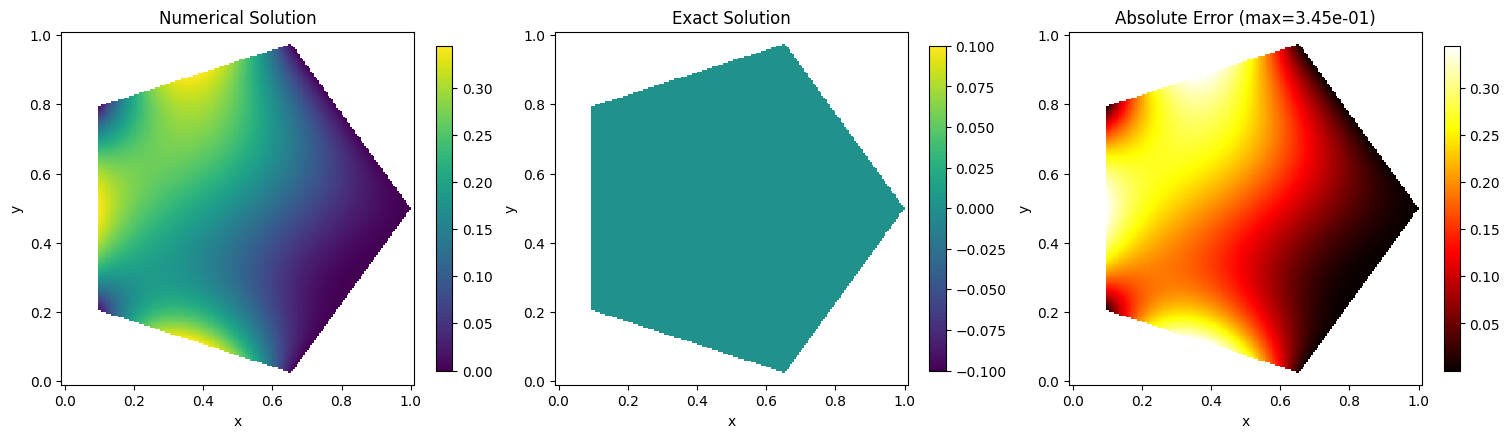

In [106]:
importlib.reload(cWEB)
importlib.reload(PDE_testcases)
importlib.reload(Geomertry)
import inhomogenous_boundary as ihbnd
importlib.reload(ihbnd)

# Analytical 5-output pentagon distance model.
# Use the scalar adapter for run_example, and keep the 5-output model for model_ms.
#model_MS = netdefs.load_test_model("SIREN_pentagon_MSSDF_02", "SIREN", params={"architecture": [2, 256, 256, 256, 5], "w_0": 15, "w_hidden": 30.0})
model_MS = Geomertry.AnaliticalDistancePentagon_SideDistances(radius=1.0, rotation=0.0)
#model_MS = Geomertry.AnaliticalDistance_case_12_MS()
#model = ihbnd.sharp_min_distance_function(model_MS)
#model = ihbnd.smooth_min_distance_function(model_MS, alpha=10.0)
#model = ihbnd.sharp_min_distance_function_hollig(model=model_MS, delta = 0.05, gamma= 3)
model = ihbnd.R_func_min(model=model_MS)
# Enable return_coefficients=True so we can use the result for pointwise evaluation.
res = cWEB.run_example(
    model=model,
    n=4,
    H=200,
    function_case=11,
    verbose=True,
    plot_mode='2d',
    return_coefficients=True,
    model_ms=model_MS,
    boundary_enforcement="coons"
)

WEB-Spline Collocation: degree=4, H=200, domain={'x1': -1, 'x2': 1, 'y1': -1, 'y2': 1}, case=11
Domain transform: [0,1]² → [-1,1]×[-1,1]
Laplacian factors in grid coords: ax=1/scale_x^2=2.500e-01, ay=1/scale_y^2=2.500e-01
Classification...
  Inner B-splines: 23788
  Outer B-splines: 1500
  Inner element arrays: 22326
Building extension matrix...
  Extension matrix: 23788 x 1500, nnz = 14240
Assembling collocation matrix...
Solving linear system...
  System dimension: 23788
  Condition number: N/A (system too large)
Evaluating solution...

Results:
  Relative max error: 5.970973e-02
  Relative L2 error:  4.950702e+00
  Mean absolute error: 2.679382e-02
  Absolute L-inf error: 5.970973e-02
  H1 semi-norm error: N/A
  H1 error:           N/A
  Condition number:   N/A
  System dimension:   23788

Timing:
  Classification/Assembly: 0.599s
  Extension:               0.236s
  Solution:                1.135s
  Total:                   1.970s


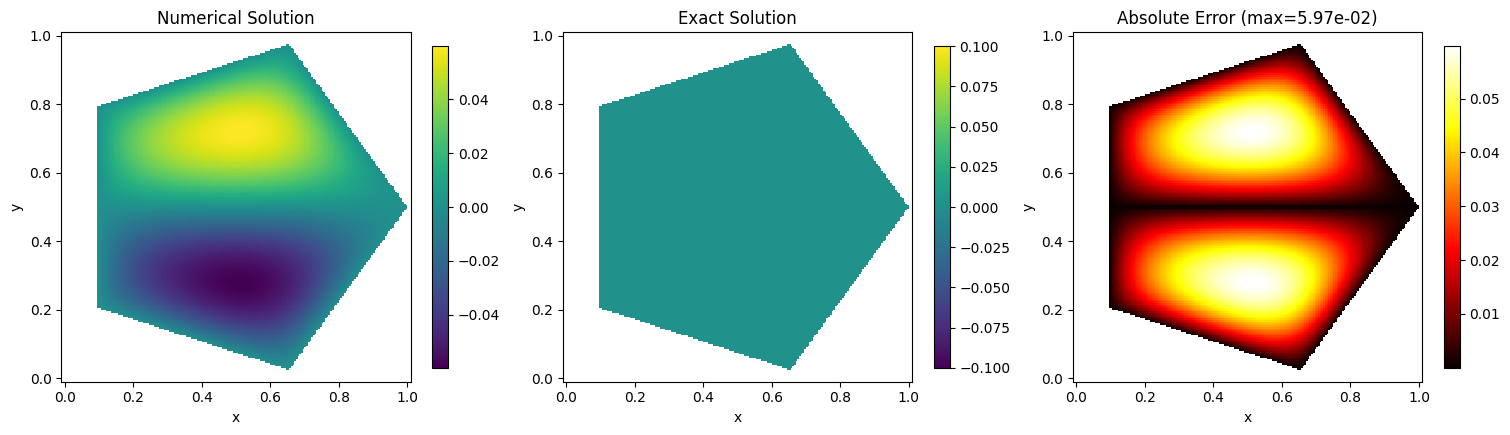

In [101]:
importlib.reload(cWEB)
importlib.reload(PDE_testcases)
importlib.reload(Geomertry)
import inhomogenous_boundary as ihbnd
importlib.reload(ihbnd)

# Analytical 5-output pentagon distance model.
# Use the scalar adapter for run_example, and keep the 5-output model for model_ms.
#model_MS = netdefs.load_test_model("SIREN_pentagon_MSSDF_02", "SIREN", params={"architecture": [2, 256, 256, 256, 5], "w_0": 15, "w_hidden": 30.0})
model_MS = Geomertry.AnaliticalDistancePentagon_SideDistances(radius=1.0, rotation=0.0)
#model = ihbnd.sharp_min_distance_function(model_MS)
#model = ihbnd.smooth_min_distance_function(model_MS, alpha=10.0)
#model = ihbnd.sharp_min_distance_function_hollig(model=model_MS, delta = 0.05, gamma= 3)
model = ihbnd.R_func_min(model=model_MS)
# Enable return_coefficients=True so we can use the result for pointwise evaluation.
res = cWEB.run_example(
    model=model,
    n=4,
    H=200,
    function_case=11,
    verbose=True,
    plot_mode='2d',
    return_coefficients=True,
    model_ms=model_MS,
    boundary_enforcement="none"
)

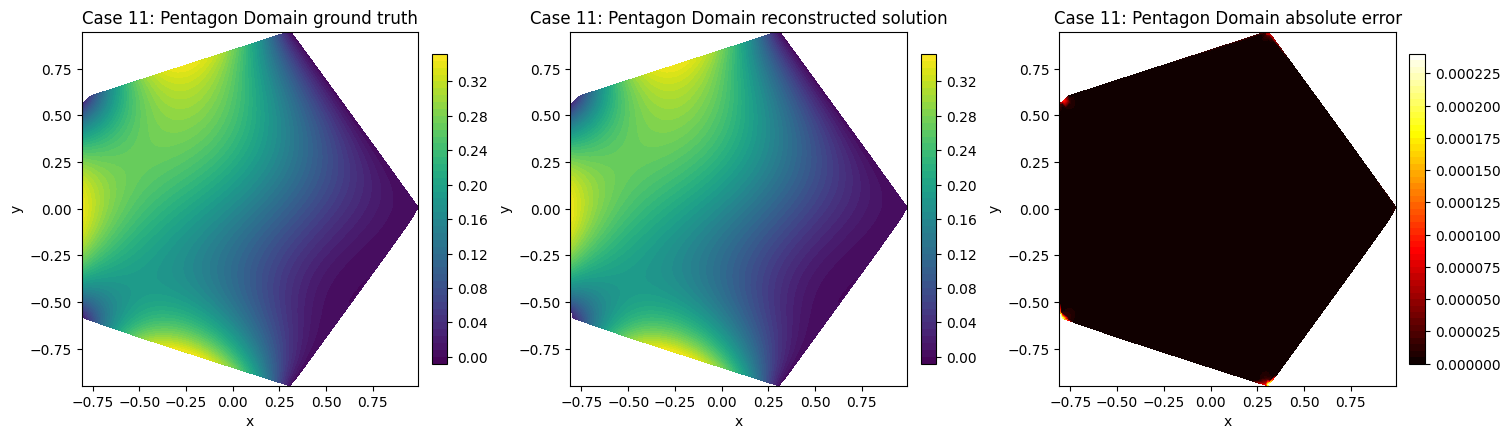


Evaluation at 10000 sample points from poisson_samples.csv
  Ground truth range: [-0.000073, 0.345088]
  Prediction range:   [-0.000073, 0.345088]
  Max absolute error: 2.356918e-04
  Mean absolute error: 3.732373e-07


In [107]:
# Plot ground truth, reconstructed solution, and absolute error at CSV sample points
importlib.reload(ihbnd)
importlib.reload(cWEB)
if 'recon_info' in res:
    result = ihbnd.plot_case_11_poisson_samples(
        recon_info=res['recon_info'],
        model=model,
        title_prefix="Case 11: Pentagon Domain",
        show=True,
        filename="poisson_samples_inhom_1_e_3.csv",
        model_ms=model_MS,
        lifting_method="coons"
    )
    print(f"\nEvaluation at {len(result['x'])} sample points from poisson_samples.csv")
    print(f"  Ground truth range: [{result['gt'].min():.6f}, {result['gt'].max():.6f}]")
    print(f"  Prediction range:   [{result['pred'].min():.6f}, {result['pred'].max():.6f}]")
    print(f"  Max absolute error: {np.abs(result['error']).max():.6e}")
    print(f"  Mean absolute error: {np.abs(result['error']).mean():.6e}")
else:
    print("Error: recon_info not found in result. Make sure return_coefficients=True was used.")

WEB-Spline Collocation: degree=4, H=200, domain={'x1': -1, 'x2': 1, 'y1': -1, 'y2': 1}, case=11
Domain transform: [0,1]² → [-1,1]×[-1,1]
Laplacian factors in grid coords: ax=1/scale_x^2=2.500e-01, ay=1/scale_y^2=2.500e-01
Classification...
  Inner B-splines: 23788
  Outer B-splines: 1500
  Inner element arrays: 22326
Building extension matrix...
  Extension matrix: 23788 x 1500, nnz = 14240
Assembling collocation matrix...
Solving linear system...
  System dimension: 23788
  Condition number: N/A (system too large)
Evaluating solution...

Results:
  Relative max error: 5.970973e-02
  Relative L2 error:  4.950702e+00
  Mean absolute error: 2.679382e-02
  Absolute L-inf error: 5.970973e-02
  H1 semi-norm error: N/A
  H1 error:           N/A
  Condition number:   N/A
  System dimension:   23788

Timing:
  Classification/Assembly: 0.581s
  Extension:               0.302s
  Solution:                1.039s
  Total:                   1.921s


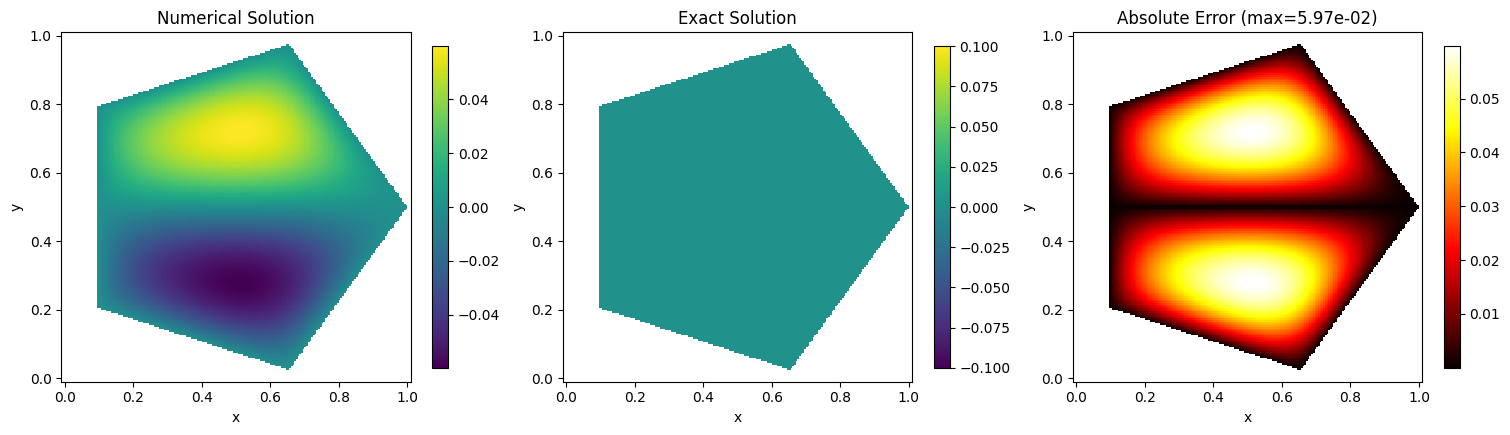

In [ ]:
importlib.reload(cWEB)
importlib.reload(PDE_testcases)
importlib.reload(Geomertry)
import inhomogenous_boundary as ihbnd
importlib.reload(ihbnd)

# Analytical 5-output pentagon distance model.
# Use the scalar adapter for run_example, and keep the 5-output model for model_ms.
#model_MS = netdefs.load_test_model("SIREN_pentagon_MSSDF_02", "SIREN", params={"architecture": [2, 256, 256, 256, 5], "w_0": 15, "w_hidden": 30.0})
model_MS_a = Geomertry.AnaliticalDistancePentagon_SideDistances(radius=1.0, rotation=0.0)
#model = ihbnd.sharp_min_distance_function(model_MS)
#model = ihbnd.smooth_min_distance_function(model_MS, alpha=10.0)
#model = ihbnd.sharp_min_distance_function_hollig(model=model_MS, delta = 0.05, gamma= 3)
model_a = ihbnd.R_func_min(model=model_MS_a)
# Enable return_coefficients=True so we can use the result for pointwise evaluation.
res_a = cWEB.run_example(
    model=model_a,
    n=4,
    H=200,
    function_case=11,
    verbose=True,
    plot_mode='2d',
    return_coefficients=True,
    model_ms=model_MS_a,
    boundary_enforcement="none"
)

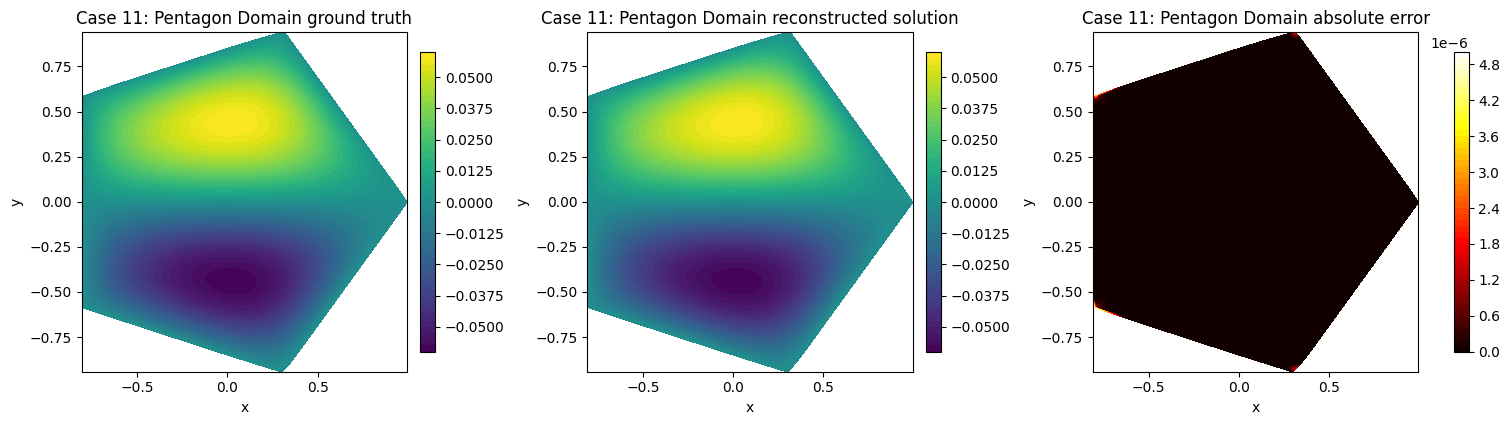


Evaluation at 10000 sample points from poisson_samples.csv
  Ground truth range: [-0.059712, 0.059685]
  Prediction range:   [-0.059712, 0.059685]
  Max absolute error: 4.930582e-06
  Mean absolute error: 5.080694e-09


In [48]:
# Plot ground truth, reconstructed solution, and absolute error at CSV sample points
importlib.reload(ihbnd)
importlib.reload(cWEB)
if 'recon_info' in res_a:
    result = ihbnd.plot_case_11_poisson_samples(
        recon_info=res_a['recon_info'],
        model=model_a,
        title_prefix="Case 11: Pentagon Domain",
        show=True,
        filename="poisson_samples_hom_1_e_3.csv",
        model_ms=model_MS_a,
        lifting_method="none"
    )
    print(f"\nEvaluation at {len(result['x'])} sample points from poisson_samples.csv")
    print(f"  Ground truth range: [{result['gt'].min():.6f}, {result['gt'].max():.6f}]")
    print(f"  Prediction range:   [{result['pred'].min():.6f}, {result['pred'].max():.6f}]")
    print(f"  Max absolute error: {np.abs(result['error']).max():.6e}")
    print(f"  Mean absolute error: {np.abs(result['error']).mean():.6e}")
else:
    print("Error: recon_info not found in result. Make sure return_coefficients=True was used.")

In [7]:
import lightning_laplace
importlib.reload(lightning_laplace)
x = 0.0
y = 0.0
solution = lightning_laplace.solve_case_11(tolerance=1e-6)
values = solution(x, y)
print(f"LightningLaplace solution at (x={x}, y={y}): {values}")

LightningLaplace solution at (x=0.0, y=0.0): 0.16261836257763207


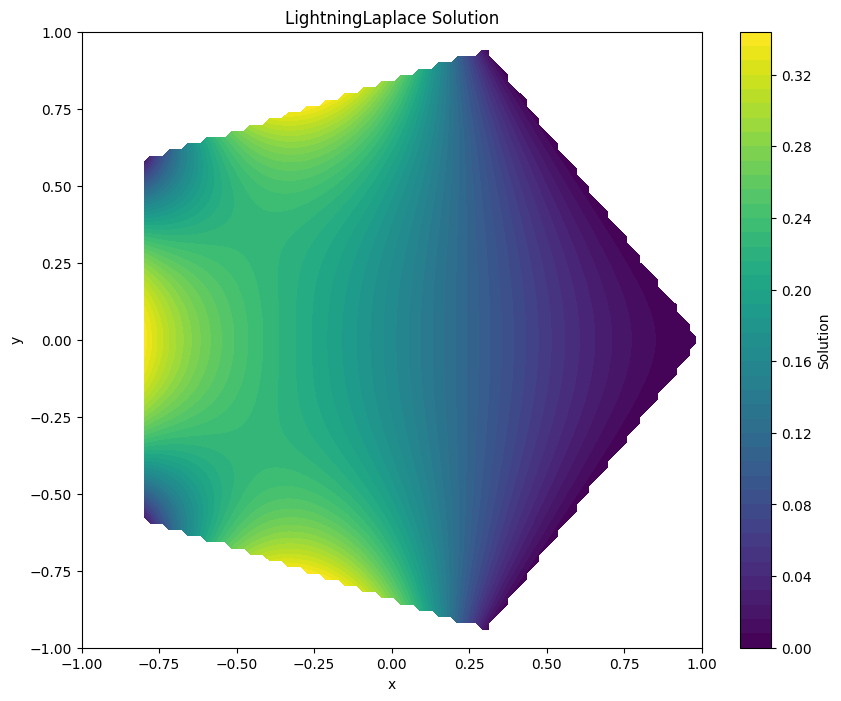

In [8]:
# plot the lightning laplace solution over the domain
X, Y = np.meshgrid(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100))
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = solution(X[i, j], Y[i, j])

valid_mask = np.array([model_a(torch.tensor([[X[i, j], Y[i, j]]], dtype=torch.float64)).item() for i in range(X.shape[0]) for j in range(X.shape[1])]).reshape(X.shape) >= 0
Z[~valid_mask] = np.nan  # Mask out points outside the domain

plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(label='Solution')
plt.xlabel('x')
plt.ylabel('y')
plt.title('LightningLaplace Solution')
plt.show()


In [ ]:
importlib.reload(cWEB)
importlib.reload(PDE_testcases)
importlib.reload(Geomertry)
import inhomogenous_boundary as ihbnd
importlib.reload(ihbnd)
import lightning_laplace
importlib.reload(lightning_laplace)

# Analytical 5-output pentagon distance model.
# Use the scalar adapter for run_example, and keep the 5-output model for model_ms.
#model_MS = netdefs.load_test_model("SIREN_pentagon_MSSDF_02", "SIREN", params={"architecture": [2, 256, 256, 256, 5], "w_0": 15, "w_hidden": 30.0})
model_MS_a = Geomertry.AnaliticalDistancePentagon_SideDistances(radius=1.0, rotation=0.0)
#model = ihbnd.sharp_min_distance_function(model_MS)
#model = ihbnd.smooth_min_distance_function(model_MS, alpha=10.0)
#model = ihbnd.sharp_min_distance_function_hollig(model=model_MS, delta = 0.05, gamma= 3)
model_a = ihbnd.R_func_min(model=model_MS_a)
# Enable return_coefficients=True so we can use the result for pointwise evaluation.
res_a = cWEB.run_example(
    model=model_a,
    n=4,
    H=200,
    function_case=11,
    verbose=True,
    plot_mode='2d',
    return_coefficients=True,
    model_ms=model_MS_a,
    boundary_enforcement="lightning"
)

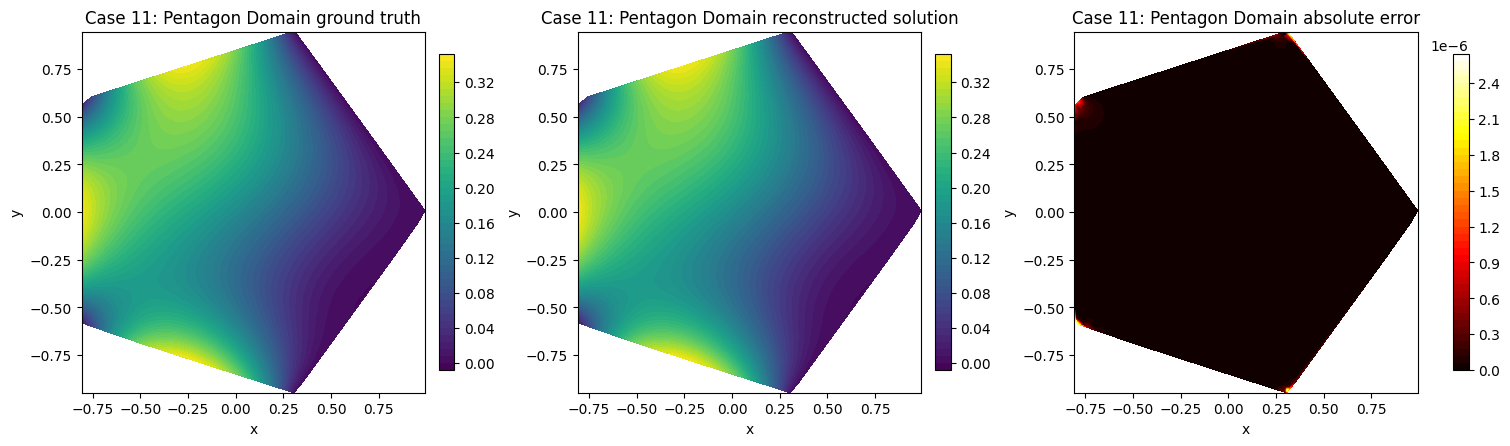


Evaluation at 10000 sample points from poisson_samples.csv
  Ground truth range: [-0.000073, 0.345088]
  Prediction range:   [-0.000073, 0.345088]
  Max absolute error: 2.629878e-06
  Mean absolute error: 8.706571e-09


In [25]:
# Plot ground truth, reconstructed solution, and absolute error at CSV sample points
importlib.reload(ihbnd)
importlib.reload(cWEB)
if 'recon_info' in res_a:
    result = ihbnd.plot_case_11_poisson_samples(
        recon_info=res_a['recon_info'],
        model=model_a,
        title_prefix="Case 11: Pentagon Domain",
        show=True,
        filename="poisson_samples_inhom_1_e_3.csv",
        model_ms=model_MS_a,
        lifting_method="lightning"
    )
    print(f"\nEvaluation at {len(result['x'])} sample points from poisson_samples.csv")
    print(f"  Ground truth range: [{result['gt'].min():.6f}, {result['gt'].max():.6f}]")
    print(f"  Prediction range:   [{result['pred'].min():.6f}, {result['pred'].max():.6f}]")
    print(f"  Max absolute error: {np.abs(result['error']).max():.6e}")
    print(f"  Mean absolute error: {np.abs(result['error']).mean():.6e}")
else:
    print("Error: recon_info not found in result. Make sure return_coefficients=True was used.")

WEB-Spline Collocation: degree=4, H=200, domain={'x1': -1, 'x2': 1, 'y1': -1, 'y2': 1}, case=11
Domain transform: [0,1]² → [-1,1]×[-1,1]
Laplacian factors in grid coords: ax=1/scale_x^2=2.500e-01, ay=1/scale_y^2=2.500e-01
Classification...
  Inner B-splines: 23788
  Outer B-splines: 1500
  Inner element arrays: 22326
Building extension matrix...
  Extension matrix: 23788 x 1500, nnz = 14240
Assembling collocation matrix...
line 1081 -> fiy this later!!! 
Solving linear system...
  System dimension: 23788
  Condition number: N/A (system too large)
Evaluating solution...

Results:
  Relative max error: 5.970973e-02
  Relative L2 error:  4.950702e+00
  Mean absolute error: 2.679382e-02
  Absolute L-inf error: 5.970973e-02
  H1 semi-norm error: N/A
  H1 error:           N/A
  Condition number:   N/A
  System dimension:   23788

Timing:
  Classification/Assembly: 0.544s
  Extension:               0.193s
  Solution:                1.067s
  Total:                   1.803s


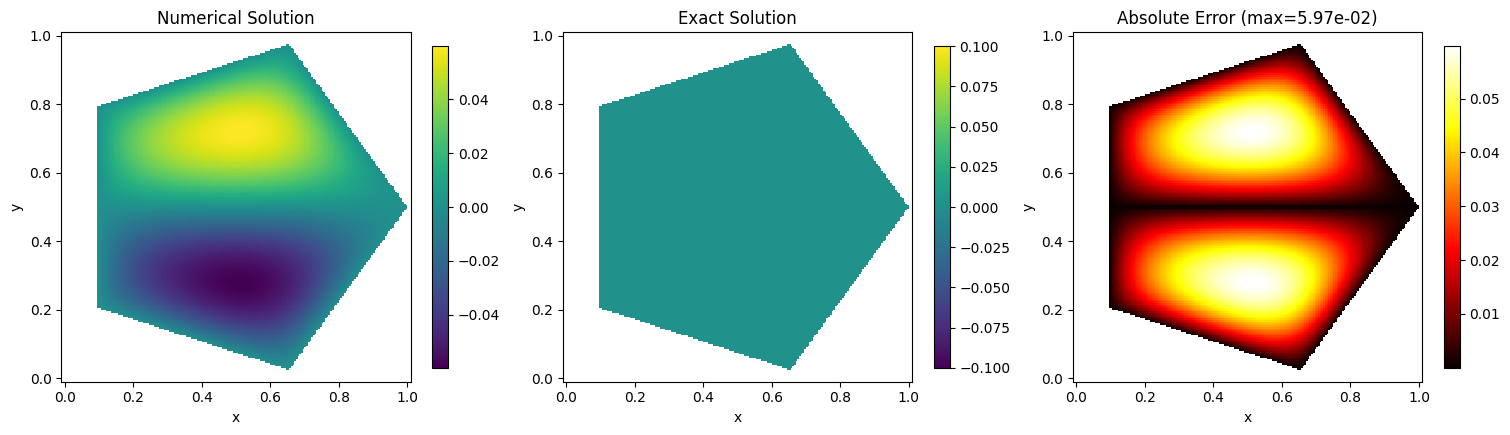

In [32]:
importlib.reload(cWEB)
importlib.reload(PDE_testcases)
importlib.reload(Geomertry)
import inhomogenous_boundary as ihbnd
importlib.reload(ihbnd)

# Analytical 5-output pentagon distance model.
# Use the scalar adapter for run_example, and keep the 5-output model for model_ms.
#model_MS = netdefs.load_test_model("SIREN_pentagon_MSSDF_02", "SIREN", params={"architecture": [2, 256, 256, 256, 5], "w_0": 15, "w_hidden": 30.0})
model_MS = Geomertry.AnaliticalDistancePentagon_SideDistances(radius=1.0, rotation=0.0)
#model = ihbnd.sharp_min_distance_function(model_MS)
#model = ihbnd.smooth_min_distance_function(model_MS, alpha=10.0)
#model = ihbnd.sharp_min_distance_function_hollig(model=model_MS, delta = 0.05, gamma= 3)
model = ihbnd.R_func_min(model=model_MS)
# Enable return_coefficients=True so we can use the result for pointwise evaluation.
res = cWEB.run_example(
    model=model,
    n=4,
    H=200,
    function_case=11,
    verbose=True,
    plot_mode='2d',
    return_coefficients=True,
    model_ms=model_MS,
    boundary_enforcement="none"
)

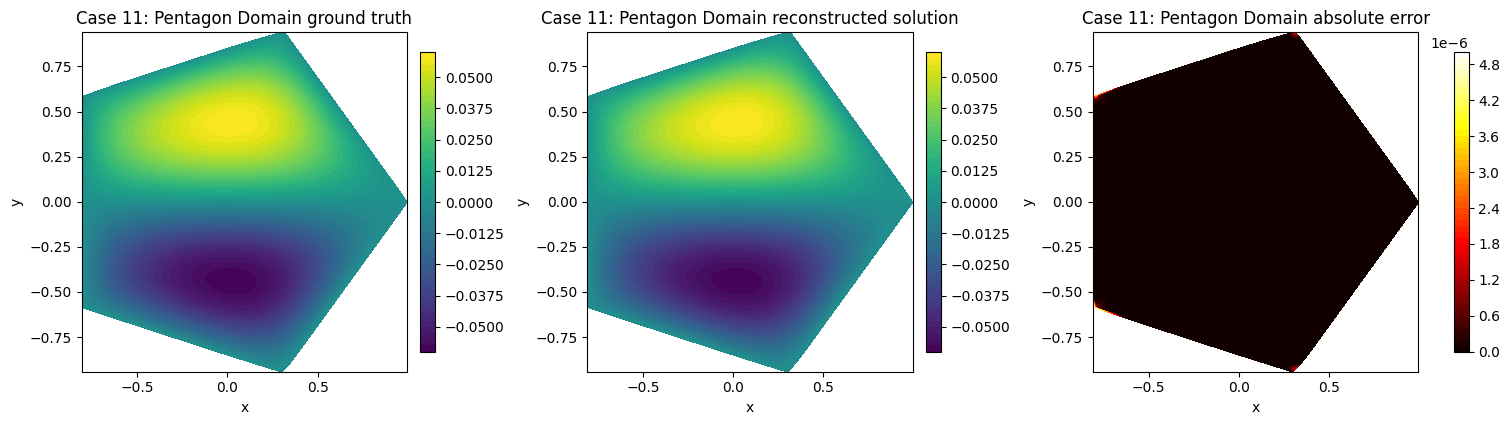


Evaluation at 10000 sample points from poisson_samples.csv
  Ground truth range: [-0.059712, 0.059685]
  Prediction range:   [-0.059712, 0.059685]
  Max absolute error: 4.930582e-06
  Mean absolute error: 5.080694e-09


In [36]:
# Plot ground truth, reconstructed solution, and absolute error at CSV sample points
importlib.reload(ihbnd)
importlib.reload(cWEB)
if 'recon_info' in res:
    result = ihbnd.plot_case_11_poisson_samples(
        recon_info=res['recon_info'],
        model=model,
        title_prefix="Case 11: Pentagon Domain",
        show=True,
        filename="poisson_samples_hom_1_e_3.csv",
        model_ms=model_MS,
        lifting_method="none"
    )
    print(f"\nEvaluation at {len(result['x'])} sample points from poisson_samples.csv")
    print(f"  Ground truth range: [{result['gt'].min():.6f}, {result['gt'].max():.6f}]")
    print(f"  Prediction range:   [{result['pred'].min():.6f}, {result['pred'].max():.6f}]")
    print(f"  Max absolute error: {np.abs(result['error']).max():.6e}")
    print(f"  Mean absolute error: {np.abs(result['error']).mean():.6e}")
else:
    print("Error: recon_info not found in result. Make sure return_coefficients=True was used.")

WEB-Spline Collocation: degree=4, H=200, domain={'x1': -1, 'x2': 1, 'y1': -1, 'y2': 1}, case=11
Domain transform: [0,1]² → [-1,1]×[-1,1]
Laplacian factors in grid coords: ax=1/scale_x^2=2.500e-01, ay=1/scale_y^2=2.500e-01
Classification...
  Inner B-splines: 23788
  Outer B-splines: 1500
  Inner element arrays: 22326
Building extension matrix...
  Extension matrix: 23788 x 1500, nnz = 14240
Assembling collocation matrix...
line 1081 -> fiy this later!!! 
Solving linear system...
  System dimension: 23788
  Condition number: N/A (system too large)
Evaluating solution...

Results:
  Relative max error: 3.445652e-01
  Relative L2 error:  2.813611e+01
  Mean absolute error: 1.559701e-01
  Absolute L-inf error: 3.445652e-01
  H1 semi-norm error: N/A
  H1 error:           N/A
  Condition number:   N/A
  System dimension:   23788

Timing:
  Classification/Assembly: 231.124s
  Extension:               0.192s
  Solution:                1.089s
  Total:                   232.406s


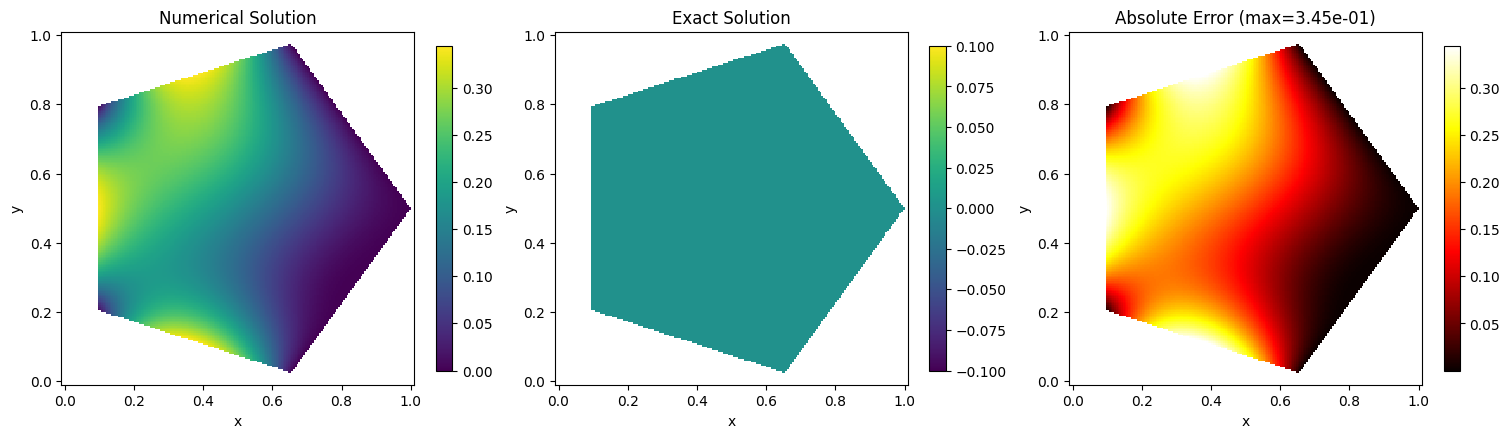

In [26]:
importlib.reload(cWEB)
importlib.reload(PDE_testcases)
importlib.reload(Geomertry)
import inhomogenous_boundary as ihbnd
importlib.reload(ihbnd)

# Analytical 5-output pentagon distance model.
# Use the scalar adapter for run_example, and keep the 5-output model for model_ms.
#model_MS = netdefs.load_test_model("SIREN_pentagon_MSSDF_02", "SIREN", params={"architecture": [2, 256, 256, 256, 5], "w_0": 15, "w_hidden": 30.0})
model_MS = Geomertry.AnaliticalDistancePentagon_SideDistances(radius=1.0, rotation=0.0)
#model = ihbnd.sharp_min_distance_function(model_MS)
#model = ihbnd.smooth_min_distance_function(model_MS, alpha=10.0)
#model = ihbnd.sharp_min_distance_function_hollig(model=model_MS, delta = 0.05, gamma= 3)
model = ihbnd.R_func_min(model=model_MS)
# Enable return_coefficients=True so we can use the result for pointwise evaluation.
res = cWEB.run_example(
    model=model,
    n=4,
    H=200,
    function_case=11,
    verbose=True,
    plot_mode='2d',
    return_coefficients=True,
    model_ms=model_MS,
    boundary_enforcement="wachspress"
)

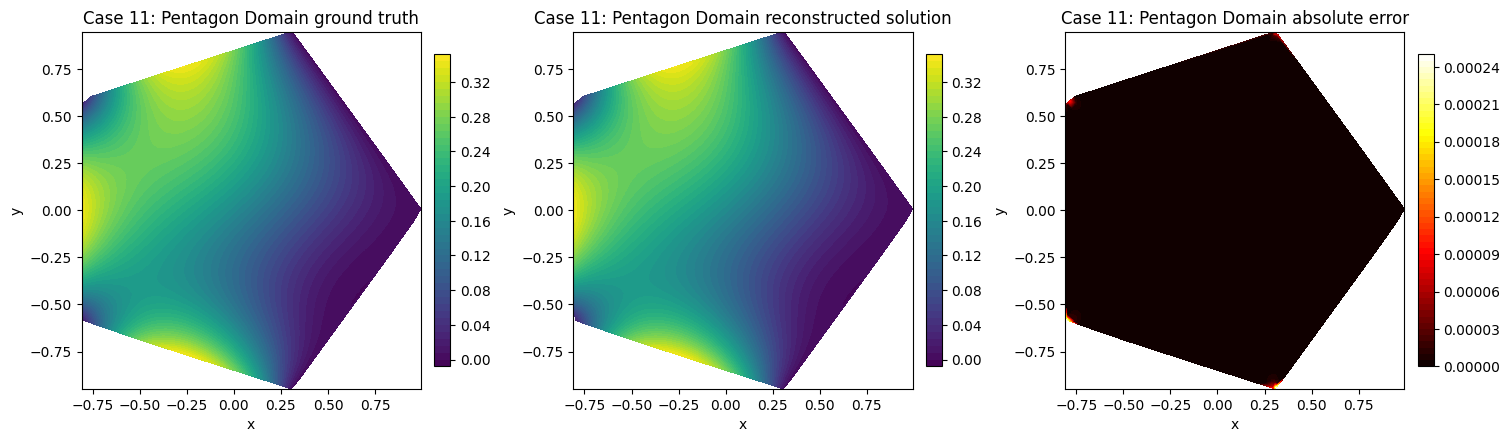


Evaluation at 10000 sample points from poisson_samples.csv
  Ground truth range: [-0.000073, 0.345088]
  Prediction range:   [-0.000073, 0.345088]
  Max absolute error: 2.475960e-04
  Mean absolute error: 3.892061e-07


In [28]:
# Plot ground truth, reconstructed solution, and absolute error at CSV sample points
importlib.reload(ihbnd)
importlib.reload(cWEB)
if 'recon_info' in res:
    result = ihbnd.plot_case_11_poisson_samples(
        recon_info=res['recon_info'],
        model=model,
        title_prefix="Case 11: Pentagon Domain",
        show=True,
        filename="poisson_samples_inhom_1_e_3.csv",
        model_ms=model_MS,
        lifting_method="wachspress"
    )
    print(f"\nEvaluation at {len(result['x'])} sample points from poisson_samples.csv")
    print(f"  Ground truth range: [{result['gt'].min():.6f}, {result['gt'].max():.6f}]")
    print(f"  Prediction range:   [{result['pred'].min():.6f}, {result['pred'].max():.6f}]")
    print(f"  Max absolute error: {np.abs(result['error']).max():.6e}")
    print(f"  Mean absolute error: {np.abs(result['error']).mean():.6e}")
else:
    print("Error: recon_info not found in result. Make sure return_coefficients=True was used.")

In [ ]:
importlib.reload(cWEB)
importlib.reload(PDE_testcases)
importlib.reload(Geomertry)
import inhomogenous_boundary as ihbnd
importlib.reload(ihbnd)
import lightning_laplace
importlib.reload(lightning_laplace)

# Analytical 5-output pentagon distance model.
# Use the scalar adapter for run_example, and keep the 5-output model for model_ms.
#model_MS = netdefs.load_test_model("SIREN_pentagon_MSSDF_02", "SIREN", params={"architecture": [2, 256, 256, 256, 5], "w_0": 15, "w_hidden": 30.0})
model_MS = Geomertry.AnaliticalDistancePentagon_SideDistances(radius=1.0, rotation=0.0)
#model = ihbnd.sharp_min_distance_function(model_MS)
#model = ihbnd.smooth_min_distance_function(model_MS, alpha=10.0)
#model = ihbnd.sharp_min_distance_function_hollig(model=model_MS, delta = 0.05, gamma= 3)
model = ihbnd.R_func_min(model=model_MS)
# Enable return_coefficients=True so we can use the result for pointwise evaluation.
res = cWEB.run_example(
    model=model,
    n=4,
    H=200,
    function_case=11,
    verbose=True,
    plot_mode='2d',
    return_coefficients=True,
    model_ms=model_MS,
    boundary_enforcement="lightning"
)

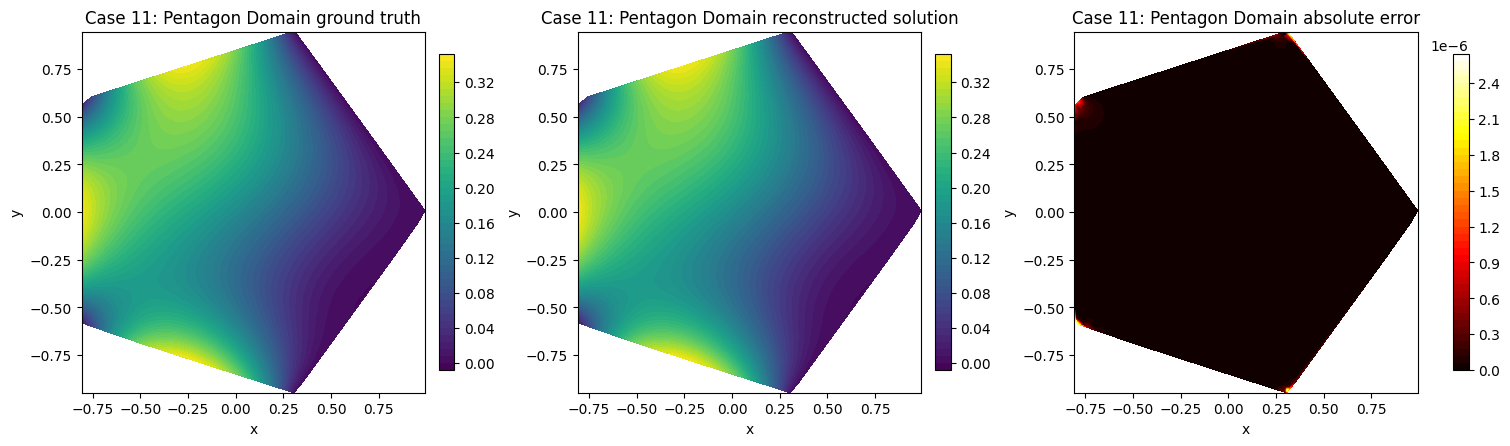


Evaluation at 10000 sample points from poisson_samples.csv
  Ground truth range: [-0.000073, 0.345088]
  Prediction range:   [-0.000073, 0.345088]
  Max absolute error: 2.629878e-06
  Mean absolute error: 8.706571e-09


In [111]:
# Plot ground truth, reconstructed solution, and absolute error at CSV sample points
importlib.reload(ihbnd)
importlib.reload(cWEB)
if 'recon_info' in res:
    result = ihbnd.plot_case_11_poisson_samples(
        recon_info=res['recon_info'],
        model=model,
        title_prefix="Case 11: Pentagon Domain",
        show=True,
        filename="poisson_samples_inhom_1_e_3.csv",
        model_ms=model_MS,
        lifting_method="lightning"
    )
    print(f"\nEvaluation at {len(result['x'])} sample points from poisson_samples.csv")
    print(f"  Ground truth range: [{result['gt'].min():.6f}, {result['gt'].max():.6f}]")
    print(f"  Prediction range:   [{result['pred'].min():.6f}, {result['pred'].max():.6f}]")
    print(f"  Max absolute error: {np.abs(result['error']).max():.6e}")
    print(f"  Mean absolute error: {np.abs(result['error']).mean():.6e}")
else:
    print("Error: recon_info not found in result. Make sure return_coefficients=True was used.")

In [ ]:
# Interpolate the scattered samples and compare the inhomogeneous and homogeneous fields
from pathlib import Path
from matplotlib.tri import LinearTriInterpolator, Triangulation
importlib.reload(ihbnd)
def find_csv(filename):
    matches = sorted(Path.cwd().rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find {filename} under {Path.cwd()}")
    return matches[0]

csv_file_inh = find_csv("poisson_samples_inhom_1_e_3.csv")
data = np.genfromtxt(csv_file_inh, delimiter=",", names=True)

csv_file_hom = find_csv("poisson_samples_hom_1_e_3.csv")
data_hom = np.genfromtxt(csv_file_hom, delimiter=",", names=True)

if data.size == 0:
    raise ValueError(f"No samples found in {csv_file_inh}")
if data_hom.size == 0:
    raise ValueError(f"No samples found in {csv_file_hom}")

pts_x = np.asarray(data["x"], dtype=np.float64).ravel()
pts_y = np.asarray(data["y"], dtype=np.float64).ravel()
gt = np.asarray(data["u"], dtype=np.float64).ravel()

pts_x_hom = np.asarray(data_hom["x"], dtype=np.float64).ravel()
pts_y_hom = np.asarray(data_hom["y"], dtype=np.float64).ravel()
gt_hom = np.asarray(data_hom["u"], dtype=np.float64).ravel()

wfct_phys = cWEB.NeuralWeightFunction(model=model, domain=None)

x_min = min(pts_x.min(), pts_x_hom.min())
x_max = max(pts_x.max(), pts_x_hom.max())
y_min = min(pts_y.min(), pts_y_hom.min())
y_max = max(pts_y.max(), pts_y_hom.max())
grid_x = np.linspace(x_min, x_max, 200)
grid_y = np.linspace(y_min, y_max, 200)
X, Y = np.meshgrid(grid_x, grid_y)

def interpolate_to_grid(x, y, values):
    triangulation = Triangulation(x, y)
    interpolator = LinearTriInterpolator(triangulation, values)
    return interpolator(X, Y)

U_inh = interpolate_to_grid(pts_x, pts_y, gt)
U_hom = interpolate_to_grid(pts_x_hom, pts_y_hom, gt_hom)
U_diff = U_inh - U_hom
#create stacked grid points for lifting function evaluation
x_flattened = np.ravel(X)
y_flattened = np.ravel(Y)
# PDE_testcases.set_function_case(11) is not required here even though function_case=11 is
# passed explicitly: get_lifting pins PDE_testcases.FUNCTION_CASE to the requested case for
# the duration of the call, so this is safe regardless of what a previous cell (e.g. the
# case-12 cells below) left the global FUNCTION_CASE set to.
lifting = ihbnd.get_lifting(model=model_MS,function_case = 11, num_sides=5, points = torch.tensor(np.column_stack((x_flattened, y_flattened)), dtype=torch.float64)).detach().cpu().numpy().reshape(X.shape)
#lifting = ihbnd.get_lifting_polygon(model=model_MS,function_case = 11, num_sides=5, points = torch.tensor(np.column_stack((x_flattened, y_flattened)), dtype=torch.float64), smoothness=1, blend_method='wachspress').detach().cpu().numpy().reshape(X.shape)
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plots = [
    (U_inh, "Interpolated data", "viridis"),
    (U_hom, "Interpolated data_hom", "viridis"),
    
]

lift_error = np.abs(lifting - U_diff)
plots2 = [
    (U_diff, "Interpolated difference: data - data_hom", "coolwarm"),
    (lifting, "Lifting function", "coolwarm"),
    (lift_error, "Lifting error", "viridis"),
]

for ax, (values, title, cmap) in zip(axes, plots):
    values = np.ma.masked_invalid(values)
    im = ax.contourf(X, Y, values, levels=60, cmap=cmap)
    ax.scatter(pts_x, pts_y, s=4, c='k', alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax, (values, title, cmap) in zip(axes2, plots2):
    values = np.ma.masked_invalid(values)
    im = ax.contourf(X, Y, values, levels=60, cmap=cmap)
    #ax.scatter(pts_x, pts_y, s=4, c='k', alpha=0.15)
    ax.contour(X, Y, values, levels=10, colors='k', linewidths=0.5, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal', adjustable='box')
    fig2.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

print(f"Inhomogeneous samples: {len(gt)} points")
print(f"Homogeneous samples:    {len(gt_hom)} points")
print(f"Max abs difference: {np.nanmax(np.abs(np.asarray(lift_error))):.6e}")
print(f"Mean abs difference: {np.nanmean(np.abs(np.asarray(lift_error))):.6e}")

WEB-Spline Collocation: degree=4, H=200, domain={'x1': -1, 'x2': 1, 'y1': -1, 'y2': 1}, case=12
Domain transform: [0,1]² → [-1,1]×[-1,1]
Laplacian factors in grid coords: ax=1/scale_x^2=2.500e-01, ay=1/scale_y^2=2.500e-01
Classification...
  Inner B-splines: 5014
  Outer B-splines: 776
  Inner element arrays: 4278
Building extension matrix...
  Extension matrix: 5014 x 776, nnz = 6880
Assembling collocation matrix...
Solving linear system...
  System dimension: 5014
  Condition number: N/A (system too large)
Evaluating solution...

Results:
  Relative max error: 1.436655e-01
  Relative L2 error:  5.284722e+00
  Mean absolute error: 6.324026e-02
  Absolute L-inf error: 1.436655e-01
  H1 semi-norm error: N/A
  H1 error:           N/A
  Condition number:   N/A
  System dimension:   5014

Timing:
  Classification/Assembly: 22.227s
  Extension:               0.051s
  Solution:                0.120s
  Total:                   22.398s


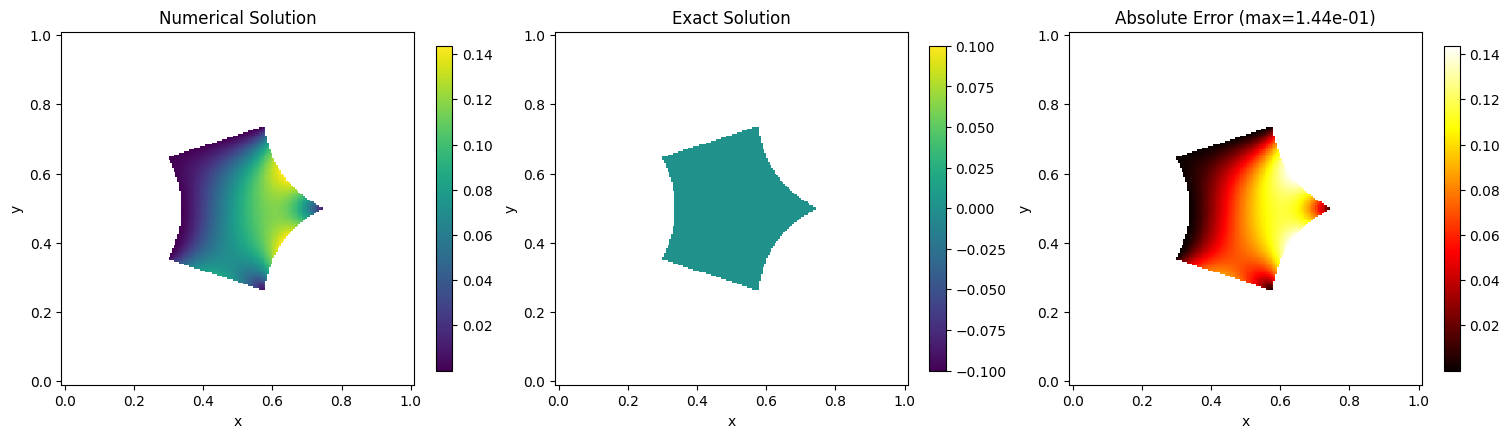

In [139]:
importlib.reload(cWEB)
importlib.reload(PDE_testcases)
importlib.reload(Geomertry)
import inhomogenous_boundary as ihbnd
importlib.reload(ihbnd)
import lightning_laplace
importlib.reload(lightning_laplace)

# Analytical 5-output pentagon distance model.
# Use the scalar adapter for run_example, and keep the 5-output model for model_ms.
model_MS = Geomertry.AnaliticalDistance_case_12_MS()

model = ihbnd.R_func_min(model=model_MS)
# Enable return_coefficients=True so we can use the result for pointwise evaluation.
res = cWEB.run_example(
    model=model,
    n=4,
    H=200,
    function_case=12,
    verbose=True,
    plot_mode='2d',
    return_coefficients=True,
    model_ms=model_MS,
    boundary_enforcement="coons"
)

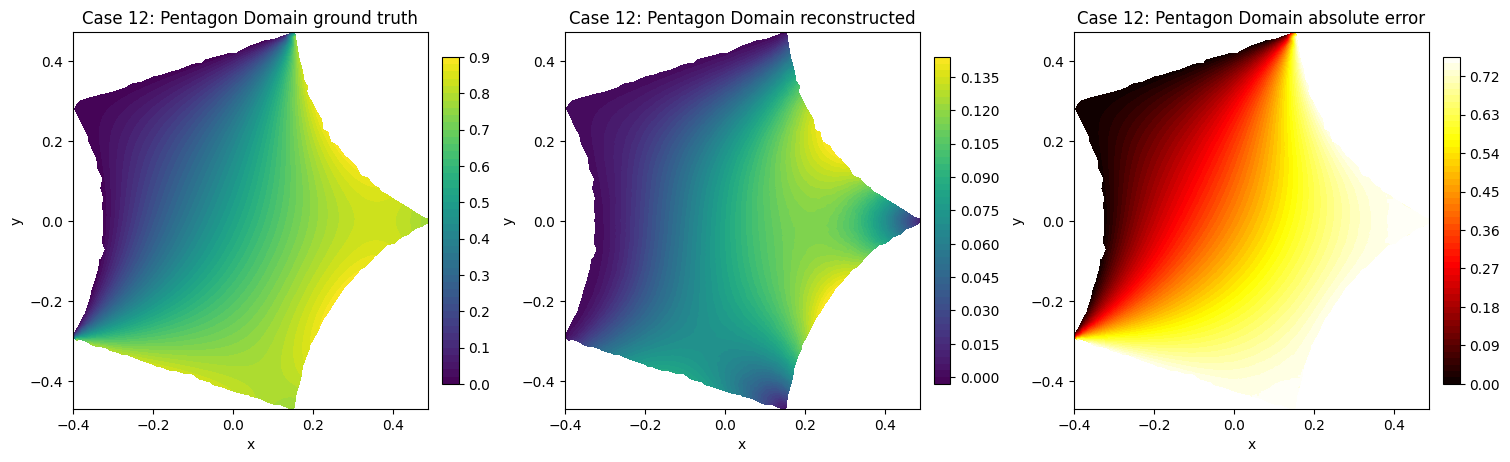


Evaluation at 10000 sample points from poisson_samples.csv
  Ground truth range: [0.000041, 0.893050]
  Prediction range:   [-0.000187, 0.143909]
  Max absolute error: 7.572131e-01
  Mean absolute error: 4.376228e-01


: 

In [ ]:
# Plot ground truth, reconstructed solution, and absolute error at CSV sample points
importlib.reload(ihbnd)
importlib.reload(cWEB)
if 'recon_info' in res:
    result = ihbnd.plot_case_12_poisson_samples(
        recon_info=res['recon_info'],
        model=model,
        csv_path=None,
        title_prefix="Case 12: Pentagon Domain",
        show=True,
        filename="poisson_samples_fun4_mixed_pentagon.csv",
        model_ms=model_MS,
        lifting_method="coons",
        plot_gradient=False,
        gradient_filename="poisson_samples_fun4_mixed_pentagon_gradient.csv",
        plot_laplacian=False,
        function_case=12,
        num_sides=5
    )
    print(f"\nEvaluation at {len(result['x'])} sample points from poisson_samples.csv")
    print(f"  Ground truth range: [{result['gt'].min():.6f}, {result['gt'].max():.6f}]")
    print(f"  Prediction range:   [{result['pred'].min():.6f}, {result['pred'].max():.6f}]")
    print(f"  Max absolute error: {np.abs(result['error']).max():.6e}")
    print(f"  Mean absolute error: {np.abs(result['error']).mean():.6e}")
else:
    print("Error: recon_info not found in result. Make sure return_coefficients=True was used.")